## import

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

# peroid

In [42]:
modelname = 'varynode'
iepoch=51
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot 
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


In [43]:
results=[]
for inode, node in enumerate(node_list):
    task = AFR2(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    thismodel = f'seed_0_{modelname}_{node}'
    model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')

    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    
    for episode in all_episode_data:
        # process
        episode['inode'] = inode
        episode['at_times'] = np.where(
            np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
        episode['at_seq'] = [float(elt[1])
                             for elt in episode['actions']]
        if episode['actions'][-1][0] == 1:
            episode['licktime'] = int(len(episode['states']))
        else:
            episode['lick_licktimetime'] = -1
        episode['trial_len'] = len(episode['actions'])

        results.append(episode)

df = pd.DataFrame(results)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/804037194.py:27: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/804037194.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


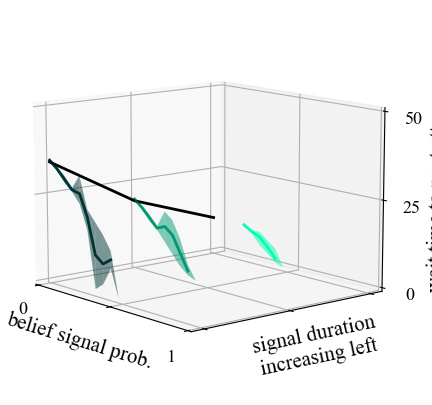

In [84]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)


for food_reward_idx in [1]:
    plotdata=[] # for plot data
    for inode, node in enumerate(node_list):
        bindata=[[] for _ in range(nbin)] 
        subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
        sb, nextatt=[],[]
        for alist, b in zip(subdf.at_times, subdf.beliefs):
            try:
                a,b=trialnextatt(alist,b),trialsb(b)  
                for j in range(len(b)):
                    thisa,thisb=a[j], b[j]
                    for i, (s,e) in enumerate(zip(bins, bins[1:])):
                        if thisa>0 and s<thisb<=e:
                            bindata[i].append(thisa)
            except:
                continue
        
        mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
        mu, err=np.array(mu), np.array(err)
        med=np.array([np.nanmedian(a) for a in bindata])
        percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
        percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
        plotdata.append([percentile_5, percentile_95, mu])

    y_values = np.arange(len(node_list)-1, -1,-1)
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    for y, (y1, y2, mu) in zip(y_values, plotdata):
        verts = []
        for i in range(len(bins) - 1):
            verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])
        
        poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(node_list)))[len(node_list)-y-1], alpha=0.5, edgecolors='none')
        ax.add_collection3d(poly)
        ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(node_list)))[len(node_list)-y-1])
    mwt=[]
    for thiswt in plotdata:
        thiswt=thiswt[0]
        i=0
        while thiswt[i]==0:
            i+=1
        mwt.append(thiswt[i])
    ax.plot(np.zeros_like(y_values),y_values,mwt ,color='black')

    ax.set_xlim(0, 1)
    # ax.set_ylim(0, 2)
    ax.set_zlim(0, 50)
    ax.set_yticks([0,1,2],[])
    ax.set_zticks([0,25,50])
    ax.set_xticks([0,0.5,1],['0','','1'])
    ax.set_xlabel('belief signal prob.',labelpad=1)
    ax.set_ylabel('signal duration\nincreasing left',labelpad=1)
    ax.set_zlabel('wait time to next attn.',labelpad=1)

    plt.tight_layout()
    ax.view_init(azim=-40, elev=11) 
    quicksave('vary node 3d p','plot wait time', fig=fig)
    plt.show()



/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/820730182.py:28: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


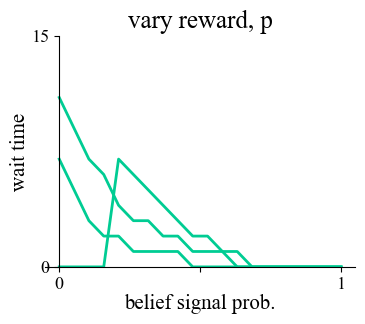

In [107]:
# imshow 2d lower tri
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)

for food_reward_idx in [1]:
    plotdata=[] # for plot data
    fig,ax = plt.subplots(1,1,figsize=(4,3))
    for inode, node in enumerate(node_list):
        bindata=[[] for _ in range(nbin)] 
        subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
        sb, nextatt=[],[]
        for alist, b in zip(subdf.at_times, subdf.beliefs):
            try:
                a,b=trialnextatt(alist,b),trialsb(b)  
                for j in range(len(b)):
                    thisa,thisb=a[j], b[j]
                    for i, (s,e) in enumerate(zip(bins, bins[1:])):
                        if thisa>0 and s<thisb<=e:
                            bindata[i].append(thisa)
            except:
                continue
        
        mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
        mu, err=np.array(mu), np.array(err)
        med=np.array([np.nanmedian(a) for a in bindata])
        percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
        ax.plot(bins, percentile_5,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
        centerax(ax)
    ax.set_ylim(0, 2)
    ax.set_xlabel('belief signal prob.',labelpad=1)
    ax.set_ylabel('wait time',labelpad=1)
    ax.set_yticks([0,15])
    ax.set_xticks([0,0.5,1],['0','','1'])
    ax.set_title('vary reward, p')

    quicksave('vary node waittime p','plot wait time', fig=fig)
    plt.show()



In [50]:

# vmin,vmax=0,50
# nbin=20
# # for food_reward_idx in range(len(food_reward_list)):
# #     for inode, node in enumerate(node_list):
# #         grid=np.zeros((vmax, nbin))
# #         bins=np.linspace(0,1,nbin)
# #         bindata=[[] for _ in range(nbin)] 
# #         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
# #         sb, nextatt=[],[]
# #         for alist, b in zip(subdf.at_times, subdf.beliefs):
# #             try:
# #                 a,b=trialnextatt(alist,b),trialsb(b)  
# #                 for j in range(len(b)):
# #                     thisa,thisb=a[j], b[j]
# #                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
# #                         if s<thisb<=e:
# #                             bindata[i].append(thisa)
# #             except:
# #                 continue
# #         for i in range(nbin):
# #             count=Counter(bindata[i])
# #             col=[]
# #             for j in range(vmin, vmax):
# #                 col.append(count[j])
# #             col=np.array(col)
# #             col=col/np.sum(col)
# #             grid[:,i]=col
# #         fig=plt.figure()
# #         # grid=np.log(grid)
# #         c=plt.imshow(grid,aspect='auto', origin='lower')
# #         plt.colorbar(c)
# #         plt.xlabel('prob')
# #         plt.ylabel('gap')
# #         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
# #         plt.xticks([0,nbin],[0,1])
# #         # quicksave(f'vary node, reward id {food_reward_idx}, node {node}', 'test', fig=fig)
# #         # plt.show()
# #         plt.close()

# vmin,vmax=0,50
# nbin=20
# for food_reward_idx in range(len(food_reward_list)):
#     for inode, node in enumerate(node_list):
#         grid=np.zeros((vmax, nbin))
#         bins=np.linspace(0,1,nbin)
#         bindata=[[] for _ in range(nbin)] 
#         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
#         sb, nextatt=[],[]
#         for alist, b in zip(subdf.at_times, subdf.beliefs):
#             try:
#                 a,b=trialnextatt(alist,b),trialsb(b)  
#                 for j in range(len(b)):
#                     thisa,thisb=a[j], b[j]
#                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                         if s<thisb<=e:
#                             bindata[i].append(thisa)
#             except:
#                 continue
#         for i in range(nbin):
#             count=Counter(bindata[i])
#             col=[]
#             for j in range(vmin, vmax):
#                 col.append(count[j])
#             col=np.array(col)
#             col=col/np.sum(col)
#             grid[:,i]=col
#         fig=plt.figure()
#         grid=np.log(grid)
#         c=plt.imshow(grid,aspect='auto', origin='lower')
#         plt.colorbar(c)
#         plt.xlabel('prob')
#         plt.ylabel('gap')
#         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
#         plt.xticks([0,nbin],[0,1])
#         # quicksave(f'vary node, reward id {food_reward_idx}, node {node} log', 'test', fig=fig)
#         plt.show()
#         plt.close()


# np

In [102]:
modelname = 'vary node np v2'
iepoch=13 # 15
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot 
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


In [103]:
results=[]
for inode, node in enumerate(node_list):
    task = AFR2(spec={'agent': 
                                        {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    thismodel = f'seed{seed}_{modelname}_n{node}_ep{iepoch}'
    model = PPO.load(f'ycstore/{thismodel}')

    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    
    for episode in all_episode_data:
        # process
        episode['inode'] = inode
        episode['at_times'] = np.where(
            np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
        episode['at_seq'] = [float(elt[1])
                             for elt in episode['actions']]
        if episode['actions'][-1][0] == 1:
            episode['licktime'] = int(len(episode['states']))
        else:
            episode['lick_licktimetime'] = -1
        episode['trial_len'] = len(episode['actions'])

        results.append(episode)

df = pd.DataFrame(results)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/87287295.py:27: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/87287295.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


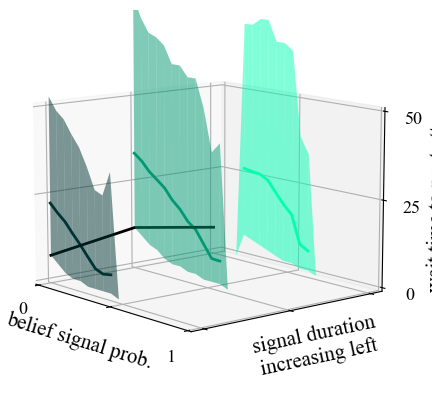

In [104]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)


for food_reward_idx in [1]:
    plotdata=[] # for plot data
    for inode, node in enumerate(node_list):
        bindata=[[] for _ in range(nbin)] 
        subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
        sb, nextatt=[],[]
        for alist, b in zip(subdf.at_times, subdf.beliefs):
            try:
                a,b=trialnextatt(alist,b),trialsb(b)  
                for j in range(len(b)):
                    thisa,thisb=a[j], b[j]
                    for i, (s,e) in enumerate(zip(bins, bins[1:])):
                        if thisa>0 and s<thisb<=e:
                            bindata[i].append(thisa)
            except:
                continue
        
        mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
        mu, err=np.array(mu), np.array(err)
        med=np.array([np.nanmedian(a) for a in bindata])
        percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
        percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
        plotdata.append([percentile_5, percentile_95, mu])

    y_values = np.arange(len(node_list)-1, -1,-1)
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    for y, (y1, y2, mu) in zip(y_values, plotdata):
        verts = []
        for i in range(len(bins) - 1):
            verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])
        
        poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(node_list)))[len(node_list)-y-1], alpha=0.5, edgecolors='none')
        ax.add_collection3d(poly)
        ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(node_list)))[len(node_list)-y-1])
    mwt=[]
    for thiswt in plotdata:
        thiswt=thiswt[0]
        i=0
        while thiswt[i]==0:
            i+=1
        mwt.append(thiswt[i])
    ax.plot(np.zeros_like(y_values),y_values,mwt ,color='black')

    ax.set_xlim(0, 1)
    # ax.set_ylim(0, 2)
    ax.set_zlim(0, 50)
    ax.set_yticks([0,1,2],[])
    ax.set_zticks([0,25,50])
    ax.set_xticks([0,0.5,1],['0','','1'])
    ax.set_xlabel('belief signal prob.',labelpad=1)
    ax.set_ylabel('signal duration\nincreasing left',labelpad=1)
    ax.set_zlabel('wait time to next attn.',labelpad=1)

    plt.tight_layout()
    ax.view_init(azim=-40, elev=11) 
    quicksave('vary node 3d np','plot wait time', fig=fig)
    plt.show()



/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/3588930850.py:25: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_67877/3588930850.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


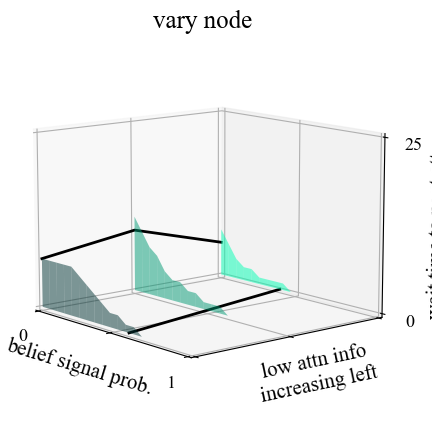

In [105]:
# imshow 3d lower tri
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)

for food_reward_idx in [1]:
    plotdata=[] # for plot data
    for inode, p1p2 in enumerate(node_list):
        bindata=[[] for _ in range(nbin)] 
        subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
        sb, nextatt=[],[]
        for alist, b in zip(subdf.at_times, subdf.beliefs):
            try:
                a,b=trialnextatt(alist,b),trialsb(b)  
                for j in range(len(b)):
                    thisa,thisb=a[j], b[j]
                    for i, (s,e) in enumerate(zip(bins, bins[1:])):
                        if thisa>0 and s<thisb<=e:
                            bindata[i].append(thisa)
            except:
                continue
        
        mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
        mu, err=np.array(mu), np.array(err)
        med=np.array([np.nanmedian(a) for a in bindata])
        percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
        plotdata.append(percentile_5)
    plotdata[0][:4]=7
    y_values = np.arange(len(node_list))
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    for y, z in zip(y_values, plotdata):
        verts = []
        for i in range(len(bins) - 1):
            verts.append([(bins[i], y, 0), (bins[i+1], y, 0), (bins[i+1], y, z[i+1]), (bins[i], y, z[i])])
        poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(node_list)))[len(node_list)-y-1], alpha=0.5, edgecolors='none')
        ax.add_collection3d(poly)
    ax.plot([0,0,0],[0,1,2],[7,9,5], color='black')
    ax.plot(np.array([12,10,8])/20,[0,1,2],[0,0,0], color='black')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_zlim(0, 2)
    ax.set_yticks([0,1,2],[])
    ax.set_zticks([0,25])
    ax.set_xticks([0,0.5,1],['0','','1'])
    ax.set_xlabel('belief signal prob.',labelpad=1)
    ax.set_ylabel('low attn info\nincreasing left',labelpad=1)
    ax.set_zlabel('wait time to next attn.',labelpad=1)

    plt.tight_layout()
    ax.view_init(azim=-40, elev=11) 
    quicksave('vary node 3d small tri','plot wait time', fig=fig)
    plt.title('vary node')
    plt.show()



In [90]:
plotdata

[array([0., 0., 0., 0., 7., 6., 5., 3., 2., 2., 1., 1., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([9., 6., 5., 3., 3., 2., 2., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([5., 4., 3., 2., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])]

In [106]:

# vmin,vmax=0,50
# nbin=20
# for food_reward_idx in range(len(food_reward_list)):
#     for inode, node in enumerate(node_list):
#         grid=np.zeros((vmax, nbin))
#         bins=np.linspace(0,1,nbin)
#         bindata=[[] for _ in range(nbin)] 
#         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
#         sb, nextatt=[],[]
#         for alist, b in zip(subdf.at_times, subdf.beliefs):
#             try:
#                 a,b=trialnextatt(alist,b),trialsb(b)  
#                 for j in range(len(b)):
#                     thisa,thisb=a[j], b[j]
#                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                         if s<thisb<=e:
#                             bindata[i].append(thisa)
#             except:
#                 continue
#         for i in range(nbin):
#             count=Counter(bindata[i])
#             col=[]
#             for j in range(vmin, vmax):
#                 col.append(count[j])
#             col=np.array(col)
#             col=col/np.sum(col)
#             grid[:,i]=col
#         fig=plt.figure()
#         # grid=np.log(grid)
#         c=plt.imshow(grid,aspect='auto', origin='lower')
#         plt.colorbar(c)
#         plt.xlabel('prob')
#         plt.ylabel('gap')
#         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
#         plt.xticks([0,nbin],[0,1])
#         quicksave(f'vary node np, reward id {food_reward_idx}, node {node}', 'test', fig=fig)
#         # plt.show()
#         plt.close()

# vmin,vmax=0,50
# nbin=20
# for food_reward_idx in range(len(food_reward_list)):
#     for inode, node in enumerate(node_list):
#         grid=np.zeros((vmax, nbin))
#         bins=np.linspace(0,1,nbin)
#         bindata=[[] for _ in range(nbin)] 
#         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.inode==inode)]
#         sb, nextatt=[],[]
#         for alist, b in zip(subdf.at_times, subdf.beliefs):
#             try:
#                 a,b=trialnextatt(alist,b),trialsb(b)  
#                 for j in range(len(b)):
#                     thisa,thisb=a[j], b[j]
#                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                         if s<thisb<=e:
#                             bindata[i].append(thisa)
#             except:
#                 continue
#         for i in range(nbin):
#             count=Counter(bindata[i])
#             col=[]
#             for j in range(vmin, vmax):
#                 col.append(count[j])
#             col=np.array(col)
#             col=col/np.sum(col)
#             grid[:,i]=col
#         fig=plt.figure()
#         grid=np.log(grid)
#         c=plt.imshow(grid,aspect='auto', origin='lower')
#         plt.colorbar(c)
#         plt.xlabel('prob')
#         plt.ylabel('gap')
#         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
#         plt.xticks([0,nbin],[0,1])
#         quicksave(f'vary node np, reward id {food_reward_idx}, node {node} log', 'test', fig=fig)
#         # plt.show()
#         plt.close()
